In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional, Set, Dict
from collections import defaultdict

RANDOM_SEED = 41
np.random.seed(RANDOM_SEED)

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import DataStructs
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

2.4570930029063356
1.43432680120807
8.2521
-6.8762


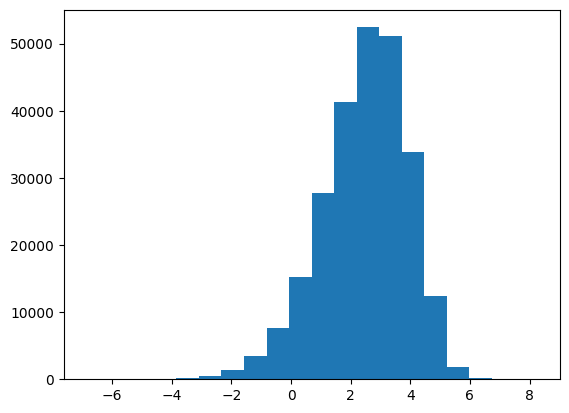

In [3]:
df = pd.read_csv("250k_rndm_zinc_drugs_clean_3.csv")

logPData = df["logP"].to_numpy()

print(logPData.mean())
print(logPData.std())
print(logPData.max())
print(logPData.min())

plt.hist(logPData, bins=20)
plt.show()

In [4]:
smiles_logP_dictionary = {}

for i, row in df.iterrows():
    mol = Chem.MolFromSmiles(df["smiles"][i])

    #rdMolStandardize.re

    lfg = rdMolStandardize.LargestFragmentChooser()
    mol = lfg.choose(mol)

    uncharger = rdMolStandardize.Uncharger()
    mol = uncharger.uncharge(mol)

    smiles = Chem.MolToSmiles(mol)

    smiles_value = smiles_logP_dictionary.get(smiles)
    if smiles_value == None:
        smiles_logP_dictionary[smiles] = (df["logP"][i], 1)
    else:
        smiles_logP_dictionary[smiles] = ((smiles_value[0]*smiles_value[1] + df["logP"][i])/(smiles_value[1]+1), smiles_value[1]+1)

print(f"{len(df["smiles"])} molecules reduced to {len(smiles_logP_dictionary)} smiles")

249455 molecules reduced to 249436 smiles


In [5]:
scaffold_dictionary = defaultdict(list)
valence_invalids = 0

for smiles, value in smiles_logP_dictionary.items():
    mol = Chem.MolFromSmiles(smiles)

    try: # From what I've understood, there are atoms with more than 4 bonds in the dataset, catch these errors and skip them.
        scaffold = MurckoScaffold.MakeScaffoldGeneric(mol)
    except Chem.AtomValenceException:
        valence_invalids += 1
        continue

    scaffold_smiles = Chem.MolToSmiles(scaffold, canonical=True)

    if scaffold_smiles != '' and scaffold.GetNumAtoms() > 0:
            scaffold_dictionary[scaffold_smiles].append(smiles)

print(f"{valence_invalids} molecules had invalid valences")
print(f"{len(smiles_logP_dictionary)} smiles reduced to {len(scaffold_dictionary)} scaffolds")

1 molecules had invalid valences
249436 smiles reduced to 219698 scaffolds


In [ ]:
training_fraction = 0.6
validation_fraction = 0.2
test_fraction = 1 - training_fraction - validation_fraction # 0.2

training_size = len(smiles_logP_dictionary) * training_fraction
validation_size = len(smiles_logP_dictionary) * validation_fraction
test_size = len(smiles_logP_dictionary) * test_fraction

training_set = []
validation_set = []
test_set = []

for references in scaffold_dictionary.values():
    if len(references) + len(test_set) <= test_size:
        for smiles in references:
            test_set.append((smiles, smiles_logP_dictionary[smiles][0]))
    elif len(references) + len(validation_set) <= validation_size:
        for smiles in references:
            validation_set.append((smiles, smiles_logP_dictionary[smiles][0]))
    elif len(references) + len(training_set) <= training_size:
        for smiles in references:
            training_set.append((smiles, smiles_logP_dictionary[smiles][0]))

print(len(test_set))
print(test_size)

49887
49887.200000000004


In [ ]:
from __future__ import annotations

"""
Scaffold-based splitter with:
- One global hold-out set (by scaffold, no leakage)
- k-fold cross-validation on the remaining data
- Optional per-fold validation split (by scaffold) taken only from the fold's training pool

Folder layout created:

out_dir/
  hold_out/
    hold_out.csv
  folds/
    fold_0/
      train/train.csv
      test/test.csv
      val/val.csv              (only if val_frac is not None and > 0)
    fold_1/
      ...
    ...

Output CSVs contain exactly two columns:
  smiles, pIC50
with smiles always first.

Changelog:
- v2.1: Fix overlap checking for k-fold CV (do not flag expected overlaps across folds).
- v2.1: Keep strict checks only for true leakage pairs (hold_out vs all, within-fold disjointness, test folds disjoint).
- v2.1: Warn when per_fold_test_target is infeasible given remaining data and n_folds.
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Set, Tuple, Union

import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold


@dataclass(frozen=True)
class CVSplitPaths:
    out_dir: Path
    hold_out_csv: Path
    folds_dir: Path
    fold_dirs: List[Path]


def _ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)


def _safe_mol_from_smiles(smiles: str) -> Optional[Chem.Mol]:
    if smiles is None:
        return None
    s = str(smiles).strip()
    if not s:
        return None
    try:
        mol = Chem.MolFromSmiles(s, sanitize=True)
        return mol
    except Exception:
        return None


def _scaffold_smiles_from_smiles(smiles: str, make_generic: bool = True) -> Optional[str]:
    """
    Compute Murcko scaffold SMILES from a molecule SMILES.

    Steps:
    1) Parse SMILES to RDKit Mol.
    2) Get Murcko scaffold core via GetScaffoldForMol.
    3) Optionally make scaffold generic (remove atom types).
    4) Canonicalize to SMILES.

    Returns None if parsing or scaffold extraction fails.
    """
    mol = _safe_mol_from_smiles(smiles)
    if mol is None:
        return None

    try:
        scaf_mol = MurckoScaffold.GetScaffoldForMol(mol)
    except Exception:
        return None

    if scaf_mol is None or scaf_mol.GetNumAtoms() == 0:
        return None

    if make_generic:
        try:
            scaf_mol = MurckoScaffold.MakeScaffoldGeneric(scaf_mol)
        except Chem.AtomValenceException:
            return None
        except Exception:
            return None

    if scaf_mol is None or scaf_mol.GetNumAtoms() == 0:
        return None

    try:
        return Chem.MolToSmiles(scaf_mol, canonical=True)
    except Exception:
        return None


def _normalize_to_dataframe(
    data: Union[pd.DataFrame, str, Path, Sequence[Union[str, Path, pd.DataFrame]]],
) -> pd.DataFrame:
    """
    Accept:
    - DataFrame
    - CSV path
    - list of DataFrames and/or CSV paths

    Return concatenated DataFrame.
    """
    if isinstance(data, pd.DataFrame):
        return data.copy()

    if isinstance(data, (str, Path)):
        return pd.read_csv(Path(data))

    parts: List[pd.DataFrame] = []
    for item in data:
        if isinstance(item, pd.DataFrame):
            parts.append(item.copy())
        else:
            parts.append(pd.read_csv(Path(item)))
    return pd.concat(parts, axis=0, ignore_index=True)


def _target_count(n_total: int, size: Union[int, float]) -> int:
    """
    Convert size to absolute count.
    - float in [0,1] means fraction of n_total
    - int means absolute count
    """
    if isinstance(size, float):
        if not (0.0 <= size <= 1.0):
            raise ValueError("If size is float, it must be in [0, 1].")
        return int(round(n_total * size))
    if isinstance(size, int):
        if size < 0:
            raise ValueError("If size is int, it must be >= 0.")
        return int(size)
    raise TypeError("size must be int or float.")


def _select_two_columns(df: pd.DataFrame, smiles_col: str, target_col: str) -> pd.DataFrame:
    """
    Return a DataFrame with exactly:
      smiles, target_col
    where smiles is always first, and is renamed from smiles_col.
    """
    if smiles_col not in df.columns:
        raise ValueError(f"Missing smiles column '{smiles_col}'. Found: {list(df.columns)}")
    if target_col not in df.columns:
        raise ValueError(f"Missing target column '{target_col}'. Found: {list(df.columns)}")

    out = df[[smiles_col, target_col]].copy()
    out = out.rename(columns={smiles_col: "smiles"})
    out = out[["smiles", target_col]]
    return out


def _group_indices_by_scaffold(
    df: pd.DataFrame,
    smiles_col: str,
    make_generic_scaffold: bool,
) -> Tuple[Dict[str, List[int]], List[int]]:
    """
    Map scaffold_smiles -> row indices in df, and track failed rows.
    """
    scaffold_to_indices: Dict[str, List[int]] = {}
    failed: List[int] = []

    for idx, smi in enumerate(df[smiles_col].astype(str).values):
        scaf = _scaffold_smiles_from_smiles(smi, make_generic=make_generic_scaffold)
        if scaf is None:
            failed.append(idx)
            continue
        scaffold_to_indices.setdefault(scaf, []).append(idx)

    return scaffold_to_indices, failed


def _assign_scaffolds_until_target(
    scaffolds: List[str],
    scaffold_to_indices: Dict[str, List[int]],
    target_count: int,
) -> Tuple[List[int], List[str]]:
    """
    Greedily take whole scaffold groups until reaching target_count.
    Because groups are indivisible, result can exceed target_count slightly.
    """
    chosen_indices: List[int] = []
    chosen_scaffolds: List[str] = []

    if target_count <= 0:
        return chosen_indices, chosen_scaffolds

    for scaf in scaffolds:
        if len(chosen_indices) >= target_count:
            break
        idxs = scaffold_to_indices[scaf]
        chosen_indices.extend(idxs)
        chosen_scaffolds.append(scaf)

    return chosen_indices, chosen_scaffolds


def _partition_scaffolds_into_k_folds_balanced(
    scaffolds: List[str],
    scaffold_to_indices: Dict[str, List[int]],
    n_folds: int,
) -> List[List[str]]:
    """
    Partition scaffold keys into n_folds, best-effort balanced by molecule counts.
    Returns list of scaffold lists, one per fold, scaffold-disjoint by construction.
    """
    if n_folds < 2:
        raise ValueError("n_folds must be >= 2 for cross-validation.")

    fold_scaffolds: List[List[str]] = [[] for _ in range(n_folds)]
    fold_counts: List[int] = [0 for _ in range(n_folds)]

    # Greedy bin packing by group sizes: assign each scaffold group to smallest fold.
    # Sort by size descending first to improve balancing.
    scaffolds_sorted = sorted(scaffolds, key=lambda s: len(scaffold_to_indices[s]), reverse=True)

    for scaf in scaffolds_sorted:
        k = int(np.argmin(fold_counts))
        fold_scaffolds[k].append(scaf)
        fold_counts[k] += len(scaffold_to_indices[scaf])

    return fold_scaffolds


def _scaffold_set_from_df(
    df: pd.DataFrame,
    smiles_col: str,
    make_generic_scaffold: bool,
) -> Set[str]:
    s: Set[str] = set()
    for smi in df[smiles_col].astype(str).values:
        scaf = _scaffold_smiles_from_smiles(smi, make_generic=make_generic_scaffold)
        if scaf is not None:
            s.add(scaf)
    return s


def _check_required_no_leakage(
    hold_out_scafs: Set[str],
    fold_train_scafs: List[Set[str]],
    fold_test_scafs: List[Set[str]],
    fold_val_scafs: Optional[List[Set[str]]],
    strict: bool,
) -> None:
    """
    Checks only the overlap constraints that matter for k-fold CV:

    Must be empty:
    - hold_out ∩ (any fold train/test/val)
    - for each fold k: train_k ∩ test_k
    - for each fold k (if val): val_k ∩ train_k, val_k ∩ test_k
    - for i != j: test_i ∩ test_j  (test folds are a partition)

    Note:
    - train_i ∩ test_j for i != j is expected to be non-empty in k-fold CV.
    """
    errors: List[str] = []

    # Hold-out vs all
    for k in range(len(fold_train_scafs)):
        if hold_out_scafs & fold_train_scafs[k]:
            errors.append(f"hold_out overlaps fold_{k}_train")
        if hold_out_scafs & fold_test_scafs[k]:
            errors.append(f"hold_out overlaps fold_{k}_test")
        if fold_val_scafs is not None:
            if hold_out_scafs & fold_val_scafs[k]:
                errors.append(f"hold_out overlaps fold_{k}_val")

    # Within-fold disjointness
    for k in range(len(fold_train_scafs)):
        if fold_train_scafs[k] & fold_test_scafs[k]:
            errors.append(f"fold_{k}: train overlaps test")
        if fold_val_scafs is not None:
            if fold_val_scafs[k] & fold_train_scafs[k]:
                errors.append(f"fold_{k}: val overlaps train")
            if fold_val_scafs[k] & fold_test_scafs[k]:
                errors.append(f"fold_{k}: val overlaps test")

    # Test folds disjoint from each other
    for i in range(len(fold_test_scafs)):
        for j in range(i + 1, len(fold_test_scafs)):
            if fold_test_scafs[i] & fold_test_scafs[j]:
                errors.append(f"test folds overlap: fold_{i}_test ∩ fold_{j}_test")

    if errors:
        msg = "Scaffold leakage detected in required constraints:\n" + "\n".join(f"  - {e}" for e in errors)
        print(msg)
        if strict:
            raise RuntimeError(msg)
    else:
        print("No scaffold leakage in required constraints (hold_out disjoint, within-fold disjoint, test folds disjoint).")


def scaffold_cv_split_write_folders(
    data: Union[pd.DataFrame, str, Path, Sequence[Union[str, Path, pd.DataFrame]]],
    out_dir: Union[str, Path],
    smiles_col: str = "mol",
    target_col: str = "pIC50",
    hold_out_size: Union[int, float] = 200,
    per_fold_test_target: Optional[int] = 500,
    val_frac: Optional[float] = None,
    n_folds: int = 5,
    random_state: int = 42,
    make_generic_scaffold: bool = True,
    strict_no_overlap: bool = True,
) -> CVSplitPaths:
    """
    Create:
    - One global scaffold-disjoint hold-out set.
    - k-fold CV splits on the remaining molecules:
        for each fold k:
          test is fold k scaffolds
          train is remaining scaffolds
          optional val is scaffold split from train only

    Important:
    - In k-fold CV, train sets across different folds overlap by design.
      Do not treat train_i ∩ test_j (i != j) as leakage.

    Output files contain only: smiles, target_col with smiles first.
    """

    rng = np.random.default_rng(random_state)

    df_raw = _normalize_to_dataframe(data).reset_index(drop=True)

    if smiles_col not in df_raw.columns:
        raise ValueError(f"Missing smiles column '{smiles_col}'. Found: {list(df_raw.columns)}")
    if target_col not in df_raw.columns:
        raise ValueError(f"Missing target column '{target_col}'. Found: {list(df_raw.columns)}")

    scaffold_to_indices, failed = _group_indices_by_scaffold(
        df=df_raw, smiles_col=smiles_col, make_generic_scaffold=make_generic_scaffold
    )

    if len(scaffold_to_indices) == 0:
        raise ValueError("No scaffolds computed. rdkiterror/parsing problem!")

    if failed:
        print(f"Note: {len(failed)} rows could not be scaffolded and will be excluded.")

    ok_mask = np.ones(len(df_raw), dtype=bool)
    ok_mask[np.array(failed, dtype=int)] = False
    df = df_raw.loc[ok_mask].reset_index(drop=True)

    scaffold_to_indices, _ = _group_indices_by_scaffold(
        df=df, smiles_col=smiles_col, make_generic_scaffold=make_generic_scaffold
    )

    scaffolds = list(scaffold_to_indices.keys())
    rng.shuffle(scaffolds)

    # Global hold-out by scaffold groups
    n_total = len(df)
    n_hold = _target_count(n_total, hold_out_size)

    hold_idx, hold_scafs = _assign_scaffolds_until_target(scaffolds, scaffold_to_indices, n_hold)
    hold_scaf_set = set(hold_scafs)

    remaining_scaffolds = [s for s in scaffolds if s not in hold_scaf_set]
    remaining_count = sum(len(scaffold_to_indices[s]) for s in remaining_scaffolds)

    if per_fold_test_target is not None:
        feasible_avg = remaining_count / float(n_folds)
        if per_fold_test_target > feasible_avg * 1.2:
            print(
                f"Warning: per_fold_test_target={per_fold_test_target} is likely infeasible. "
                f"After hold_out, remaining molecules ~{remaining_count}, so average per fold test ~{feasible_avg:.1f}."
            )

    # Partition remaining scaffolds into fold test partitions
    fold_scaffolds = _partition_scaffolds_into_k_folds_balanced(
        remaining_scaffolds, scaffold_to_indices, n_folds=n_folds
    )

    out_dir = Path(out_dir)
    hold_dir = out_dir / "hold_out"
    folds_dir = out_dir / "folds"
    _ensure_dir(out_dir)
    _ensure_dir(hold_dir)
    _ensure_dir(folds_dir)

    # Write hold-out
    hold_csv = hold_dir / "hold_out.csv"
    df_hold = _select_two_columns(df.iloc[hold_idx], smiles_col=smiles_col, target_col=target_col)
    df_hold.to_csv(hold_csv, index=False)

    def _indices_from_scaffolds(scaf_keys: List[str]) -> List[int]:
        idxs: List[int] = []
        for s in scaf_keys:
            idxs.extend(scaffold_to_indices[s])
        return idxs

    fold_dirs: List[Path] = []

    # For correct overlap checking
    hold_out_scafs = _scaffold_set_from_df(df.iloc[hold_idx], smiles_col, make_generic_scaffold)
    fold_train_scafs: List[Set[str]] = []
    fold_test_scafs: List[Set[str]] = []
    fold_val_scafs: Optional[List[Set[str]]] = [] if (val_frac is not None and val_frac > 0.0) else None

    for k in range(n_folds):
        fold_dir = folds_dir / f"fold_{k}"
        fold_dirs.append(fold_dir)

        train_dir = fold_dir / "train"
        test_dir = fold_dir / "test"
        val_dir = fold_dir / "val" if (val_frac is not None and val_frac > 0.0) else None

        _ensure_dir(train_dir)
        _ensure_dir(test_dir)
        if val_dir is not None:
            _ensure_dir(val_dir)

        test_scafs = fold_scaffolds[k]
        train_scafs = [s for i in range(n_folds) if i != k for s in fold_scaffolds[i]]

        test_idx = _indices_from_scaffolds(test_scafs)
        train_idx_all = _indices_from_scaffolds(train_scafs)

        # Optional validation split from training pool only, by scaffold
        val_idx: List[int] = []
        if val_dir is not None:
            if not (0.0 <= float(val_frac) <= 1.0):
                raise ValueError("val_frac must be in [0, 1] if provided.")

            train_scafs_unique = list(dict.fromkeys(train_scafs))
            local_rng = np.random.default_rng(random_state + 1000 + k)
            local_rng.shuffle(train_scafs_unique)

            train_pool_count = len(train_idx_all)
            n_val = int(round(train_pool_count * float(val_frac)))

            val_idx, val_scafs = _assign_scaffolds_until_target(
                train_scafs_unique, scaffold_to_indices, n_val
            )
            val_scaf_set = set(val_scafs)

            train_scafs = [s for s in train_scafs if s not in val_scaf_set]
            train_idx_all = _indices_from_scaffolds(train_scafs)

        # Write CSVs (only smiles + pIC50)
        df_test = _select_two_columns(df.iloc[test_idx], smiles_col=smiles_col, target_col=target_col)
        df_train = _select_two_columns(df.iloc[train_idx_all], smiles_col=smiles_col, target_col=target_col)

        df_test.to_csv(test_dir / "test.csv", index=False)
        df_train.to_csv(train_dir / "train.csv", index=False)

        if val_dir is not None:
            df_val = _select_two_columns(df.iloc[val_idx], smiles_col=smiles_col, target_col=target_col)
            df_val.to_csv(val_dir / "val.csv", index=False)

        # Record scaffold sets for correct overlap checks
        fold_test_scafs_set = _scaffold_set_from_df(df.iloc[test_idx], smiles_col, make_generic_scaffold)
        fold_train_scafs_set = _scaffold_set_from_df(df.iloc[train_idx_all], smiles_col, make_generic_scaffold)
        fold_test_scafs.append(fold_test_scafs_set)
        fold_train_scafs.append(fold_train_scafs_set)

        if fold_val_scafs is not None:
            fold_val_scafs_set = _scaffold_set_from_df(df.iloc[val_idx], smiles_col, make_generic_scaffold)
            fold_val_scafs.append(fold_val_scafs_set)

        if per_fold_test_target is not None:
            print(
                f"Fold {k}: test={len(test_idx)} (target {per_fold_test_target}), "
                f"train={len(train_idx_all)}"
                + (f", val={len(val_idx)}" if val_dir is not None else "")
            )
        else:
            print(
                f"Fold {k}: test={len(test_idx)}, train={len(train_idx_all)}"
                + (f", val={len(val_idx)}" if val_dir is not None else "")
            )

    # Correct leakage checks (do not compare across folds in ways that are expected to overlap)
    _check_required_no_leakage(
        hold_out_scafs=hold_out_scafs,
        fold_train_scafs=fold_train_scafs,
        fold_test_scafs=fold_test_scafs,
        fold_val_scafs=fold_val_scafs,
        strict=strict_no_overlap,
    )

    return CVSplitPaths(
        out_dir=out_dir,
        hold_out_csv=hold_csv,
        folds_dir=folds_dir,
        fold_dirs=fold_dirs,
    )


if __name__ == "__main__":
    paths = scaffold_cv_split_write_folders(
        data=r"..\bace.csv",
        out_dir="scaffold_cv_output",
        smiles_col="mol",
        target_col="pIC50",
        hold_out_size=200,
        per_fold_test_target=500,  # will warn if infeasible
        val_frac=0.1,
        n_folds=5,
        random_state=42,
        make_generic_scaffold=True,
        strict_no_overlap=True,
    )
    print(paths)

Note: 5 rows could not be scaffolded and will be excluded.
Fold 0: test=262 (target 500), train=940, val=104
Fold 1: test=261 (target 500), train=929, val=116
Fold 2: test=261 (target 500), train=924, val=121
Fold 3: test=261 (target 500), train=934, val=111
Fold 4: test=261 (target 500), train=937, val=108
No scaffold leakage in required constraints (hold_out disjoint, within-fold disjoint, test folds disjoint).
CVSplitPaths(out_dir=WindowsPath('scaffold_cv_output'), hold_out_csv=WindowsPath('scaffold_cv_output/hold_out/hold_out.csv'), folds_dir=WindowsPath('scaffold_cv_output/folds'), fold_dirs=[WindowsPath('scaffold_cv_output/folds/fold_0'), WindowsPath('scaffold_cv_output/folds/fold_1'), WindowsPath('scaffold_cv_output/folds/fold_2'), WindowsPath('scaffold_cv_output/folds/fold_3'), WindowsPath('scaffold_cv_output/folds/fold_4')])
